# Cannibalization vs Incrementality Analysis
## Estimating the Impact of New Product Launch (SKU_A3)

**Business Question:** When we launched SKU_A3, how much of its sales were:
- **Cannibalized** from our own products (SKU_A1, SKU_A2)?
- **Incremental** from competitors (Brand B, Brand C)?

**Approach:**
1. Exploratory Data Analysis
2. Pre/Post Launch Comparison
3. Build PyMC Bayesian Model
4. Estimate Cannibalization & Incrementality Effects
5. Calculate True Incremental Volume

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

# Set style
sns.set_theme(style="darkgrid")
sns.set_palette("husl")
%config InlineBackend.figure_format = 'retina'

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Explore Data

In [23]:
# Load data
df = pd.read_csv('new_product_launch_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst few rows:")
df.head(10)

Dataset Shape: (515, 9)

Columns: ['Date', 'Week', 'SKU', 'Brand', 'Price', 'ACV', 'Is_New_Product', 'Post_Launch', 'Sales_Volume']

First few rows:


,Date,Week,SKU,Brand,Price,ACV,Is_New_Product,Post_Launch,Sales_Volume
0,2023-01-02,1,SKU_A1,Brand_A,1.96,0.97,0,0,27730
1,2023-01-02,1,SKU_B1,Brand_B,1.77,0.96,0,0,34366
2,2023-01-02,1,SKU_B2,Brand_B,2.03,0.97,0,0,16430
3,2023-01-02,1,SKU_C1,Brand_C,2.21,0.84,0,0,7493
4,2023-01-09,2,SKU_A1,Brand_A,1.90,0.89,0,0,31618
5,2023-01-09,2,SKU_A2,Brand_A,2.54,0.81,0,0,5899
6,2023-01-09,2,SKU_B1,Brand_B,1.77,0.97,0,0,37740
7,2023-01-09,2,SKU_B2,Brand_B,2.36,0.95,0,0,8914
8,2023-01-09,2,SKU_C1,Brand_C,2.16,0.88,0,0,11689
9,2023-01-16,3,SKU_A1,Brand_A,1.87,0.84,0,0,33763


In [24]:
# Basic statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Date,Week,Price,ACV,Is_New_Product,Post_Launch,Sales_Volume
count,515,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,2024-01-13 13:05:42.524271872,54.792233,2.155825,0.886369,0.093204,0.543689,16084.198058
min,2023-01-02 00:00:00,1.000000,1.750000,0.400000,0.000000,0.000000,3380.000000
25%,2023-07-17 00:00:00,29.000000,1.980000,0.840000,0.000000,0.000000,9616.000000
50%,2024-01-29 00:00:00,57.000000,2.120000,0.890000,0.000000,1.000000,14530.000000
75%,2024-07-15 00:00:00,81.000000,2.320000,0.940000,0.000000,1.000000,21694.000000
max,2024-12-23 00:00:00,104.000000,2.700000,0.980000,1.000000,1.000000,49085.000000
std,NaN,30.016557,0.234104,0.064574,0.291001,0.498572,8271.281641


In [25]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\nUnique products:")
print(df.groupby('Brand')['SKU'].unique())

Missing values:
Date              0
Week              0
SKU               0
Brand             0
Price             0
ACV               0
Is_New_Product    0
Post_Launch       0
Sales_Volume      0
dtype: int64

Unique products:
Brand
Brand_A    [SKU_A1, SKU_A2, SKU_A3]
Brand_B            [SKU_B1, SKU_B2]
Brand_C                    [SKU_C1]
Name: SKU, dtype: object


## 2. Exploratory Data Analysis

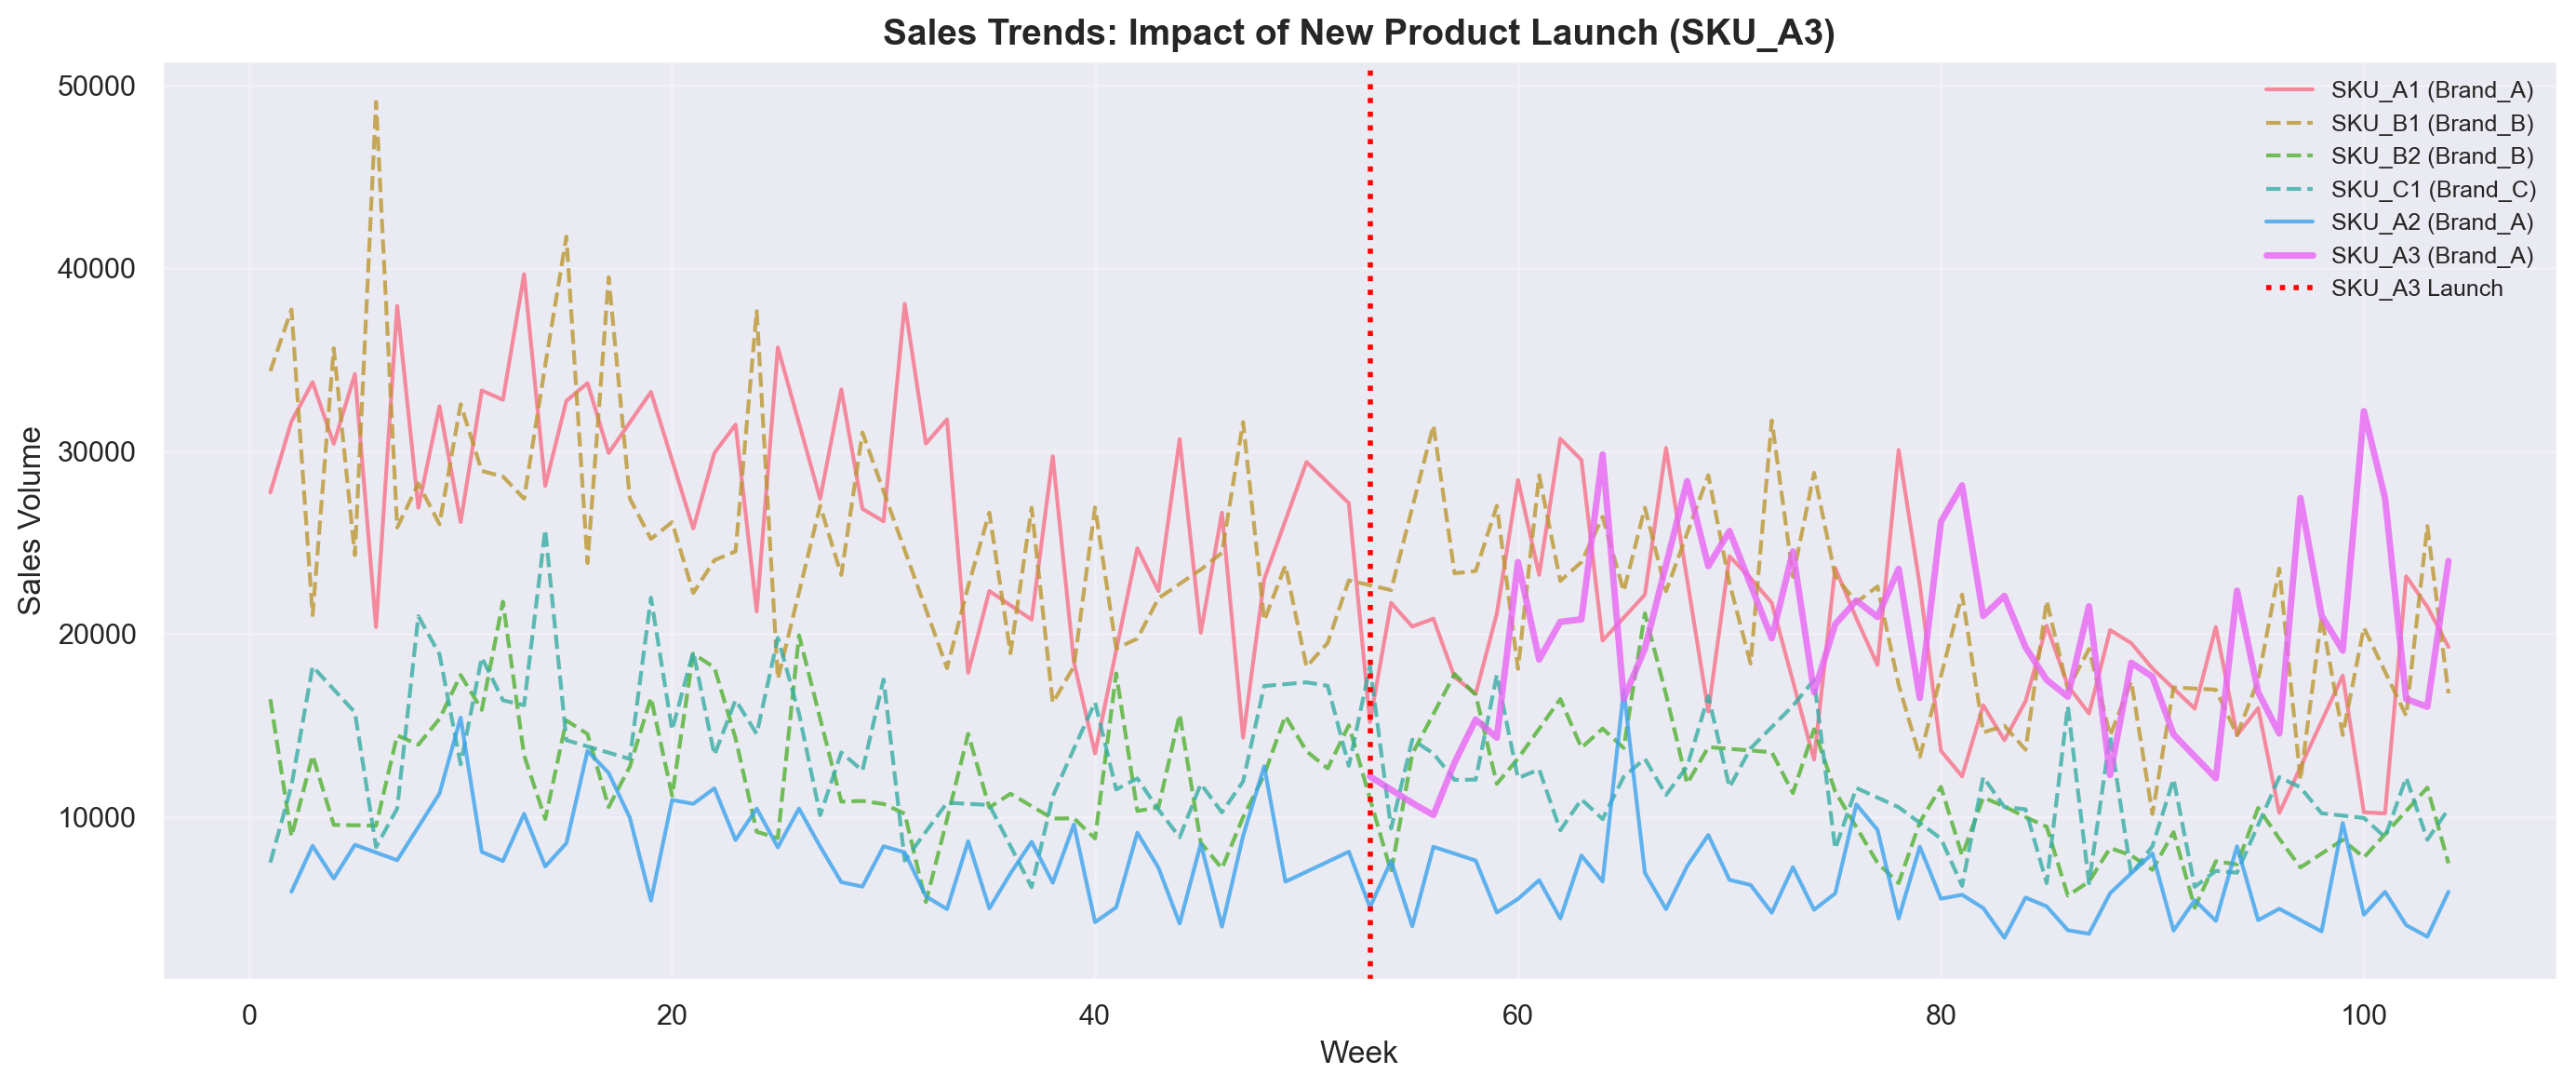


New product (SKU_A3) launched at Week 53


In [26]:
# Sales trends over time by SKU
fig, ax = plt.subplots(figsize=(14, 6))

for sku in df['SKU'].unique():
    sku_data = df[df['SKU'] == sku].sort_values('Week')
    brand = sku_data['Brand'].iloc[0]
    linestyle = '-' if brand == 'Brand_A' else '--'
    linewidth = 2.5 if sku == 'SKU_A3' else 1.5
    ax.plot(sku_data['Week'], sku_data['Sales_Volume'], 
            label=f"{sku} ({brand})", linestyle=linestyle, linewidth=linewidth, alpha=0.8)

# Mark the launch week
launch_week = df[df['Is_New_Product'] == 1]['Week'].min()
ax.axvline(x=launch_week, color='red', linestyle=':', linewidth=2, label='SKU_A3 Launch')

ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Sales Volume', fontsize=12)
ax.set_title('Sales Trends: Impact of New Product Launch (SKU_A3)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nNew product (SKU_A3) launched at Week {launch_week}")

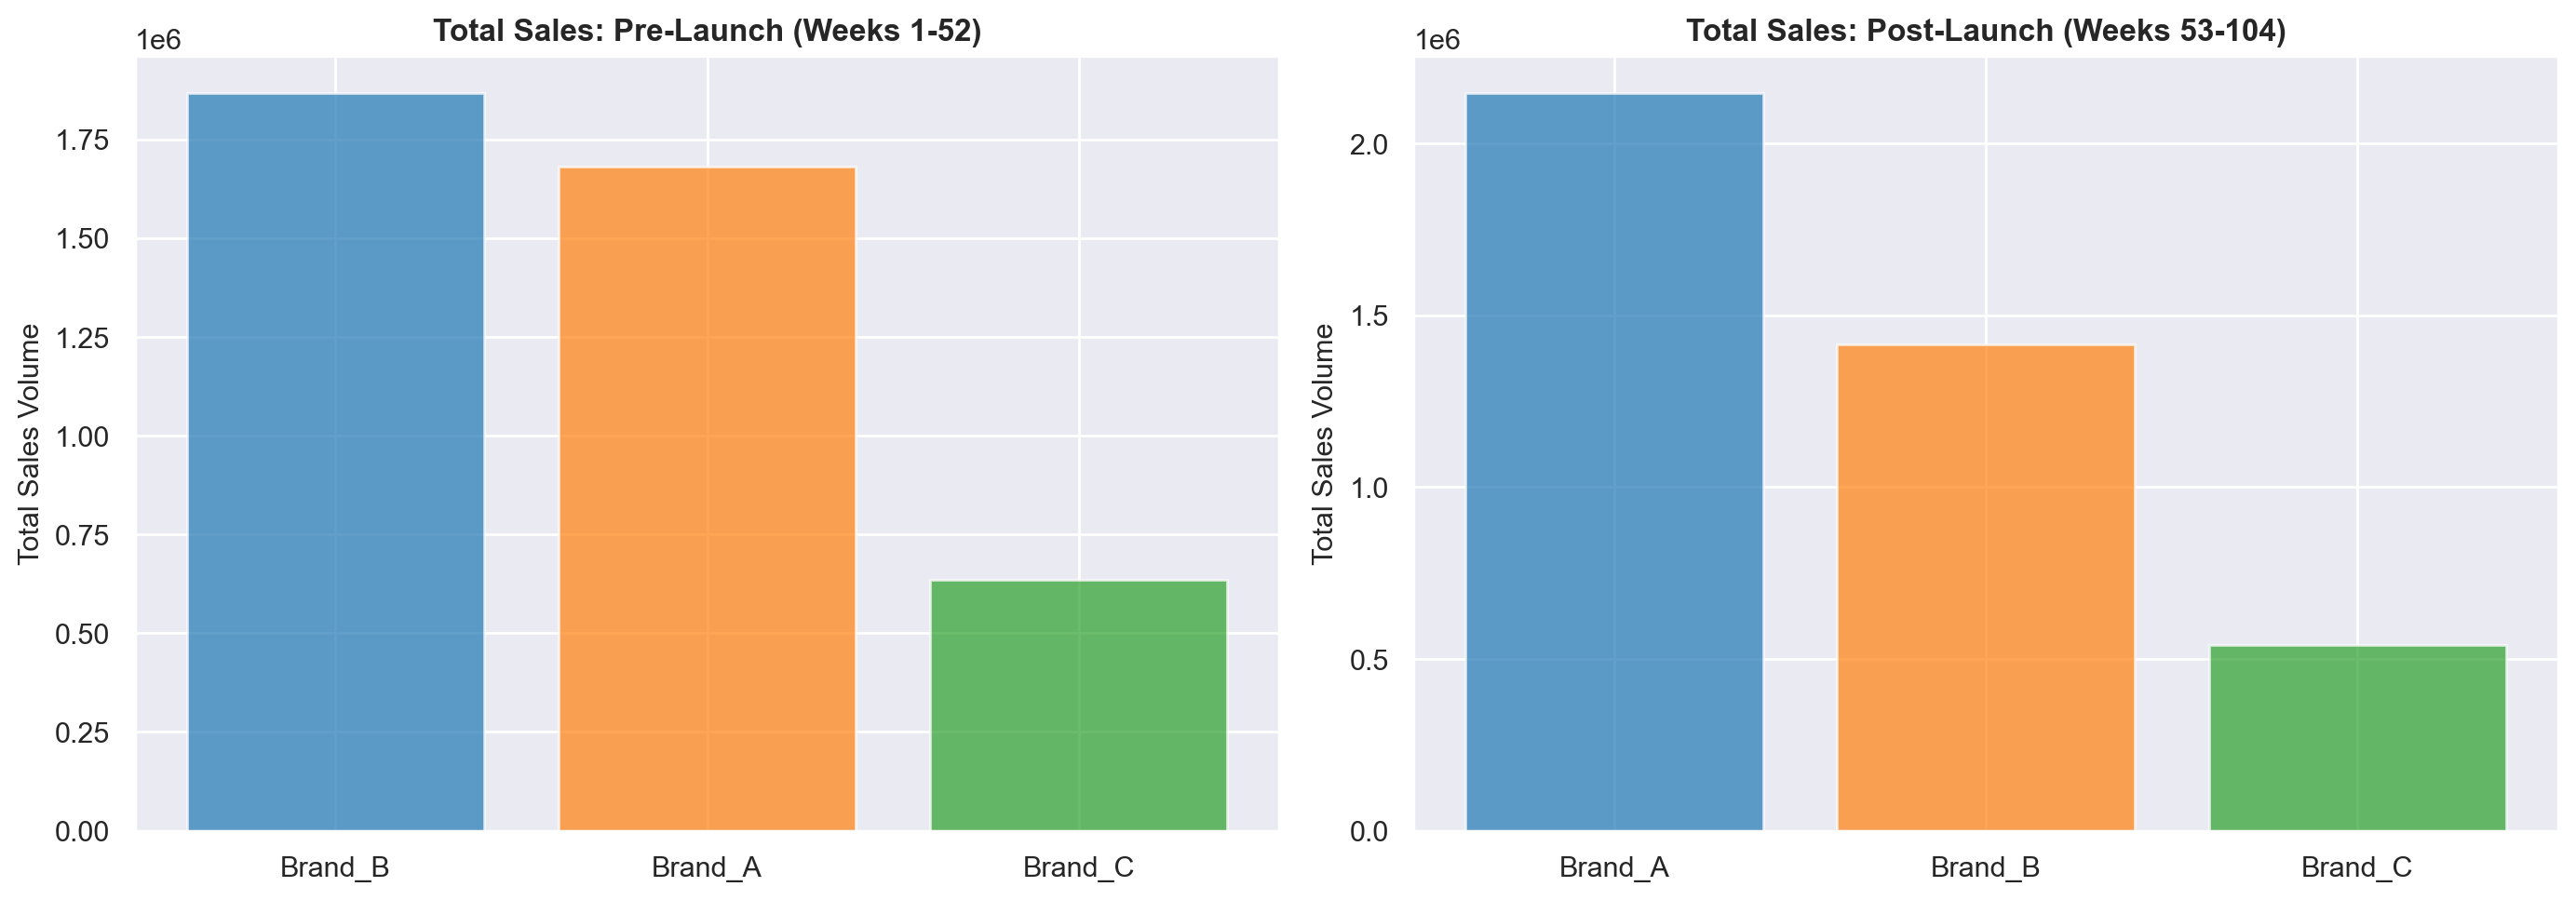

In [27]:
# Sales distribution by brand and period
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pre-launch
pre_data = df[df['Post_Launch'] == 0]
pre_summary = pre_data.groupby('Brand')['Sales_Volume'].sum().sort_values(ascending=False)
axes[0].bar(pre_summary.index, pre_summary.values, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Total Sales: Pre-Launch (Weeks 1-52)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Sales Volume', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

# Post-launch
post_data = df[df['Post_Launch'] == 1]
post_summary = post_data.groupby('Brand')['Sales_Volume'].sum().sort_values(ascending=False)
axes[1].bar(post_summary.index, post_summary.values, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Total Sales: Post-Launch (Weeks 53-104)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Sales Volume', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. Pre/Post Analysis: Evidence of Cannibalization

In [28]:
# Calculate average weekly sales pre/post launch for each SKU
pre_avg = df[df['Post_Launch'] == 0].groupby('SKU')['Sales_Volume'].mean()
post_avg = df[(df['Post_Launch'] == 1) & (df['Is_New_Product'] == 0)].groupby('SKU')['Sales_Volume'].mean()

comparison = pd.DataFrame({
    'Pre_Launch_Avg': pre_avg,
    'Post_Launch_Avg': post_avg,
})
comparison['Change'] = comparison['Post_Launch_Avg'] - comparison['Pre_Launch_Avg']
comparison['Change_Pct'] = (comparison['Change'] / comparison['Pre_Launch_Avg'] * 100).round(1)
comparison['Brand'] = [df[df['SKU'] == sku]['Brand'].iloc[0] for sku in comparison.index]

print("Average Weekly Sales Impact (Existing Products):")
print(comparison.sort_values('Change_Pct'))

# New product stats
new_product_sales = df[df['Is_New_Product'] == 1]['Sales_Volume']
print(f"\nNew Product (SKU_A3) Stats:")
print(f"  Total Sales: {new_product_sales.sum():,}")
print(f"  Avg Weekly Sales: {new_product_sales.mean():.0f}")
print(f"  Weeks in Market: {len(new_product_sales)}")

Average Weekly Sales Impact (Existing Products):
        Pre_Launch_Avg  Post_Launch_Avg       Change  Change_Pct    Brand
SKU                                                                      
SKU_A1    27885.630435     19415.000000 -8470.630435       -30.4  Brand_A
SKU_A2     8271.041667      6155.204082 -2115.837585       -25.6  Brand_A
SKU_B1    26497.234043     20678.217391 -5819.016651       -22.0  Brand_B
SKU_C1    14120.222222     11247.937500 -2872.284722       -20.3  Brand_C
SKU_B2    12689.795918     10785.302326 -1904.493593       -15.0  Brand_B

New Product (SKU_A3) Stats:
  Total Sales: 951,471
  Avg Weekly Sales: 19822
  Weeks in Market: 48


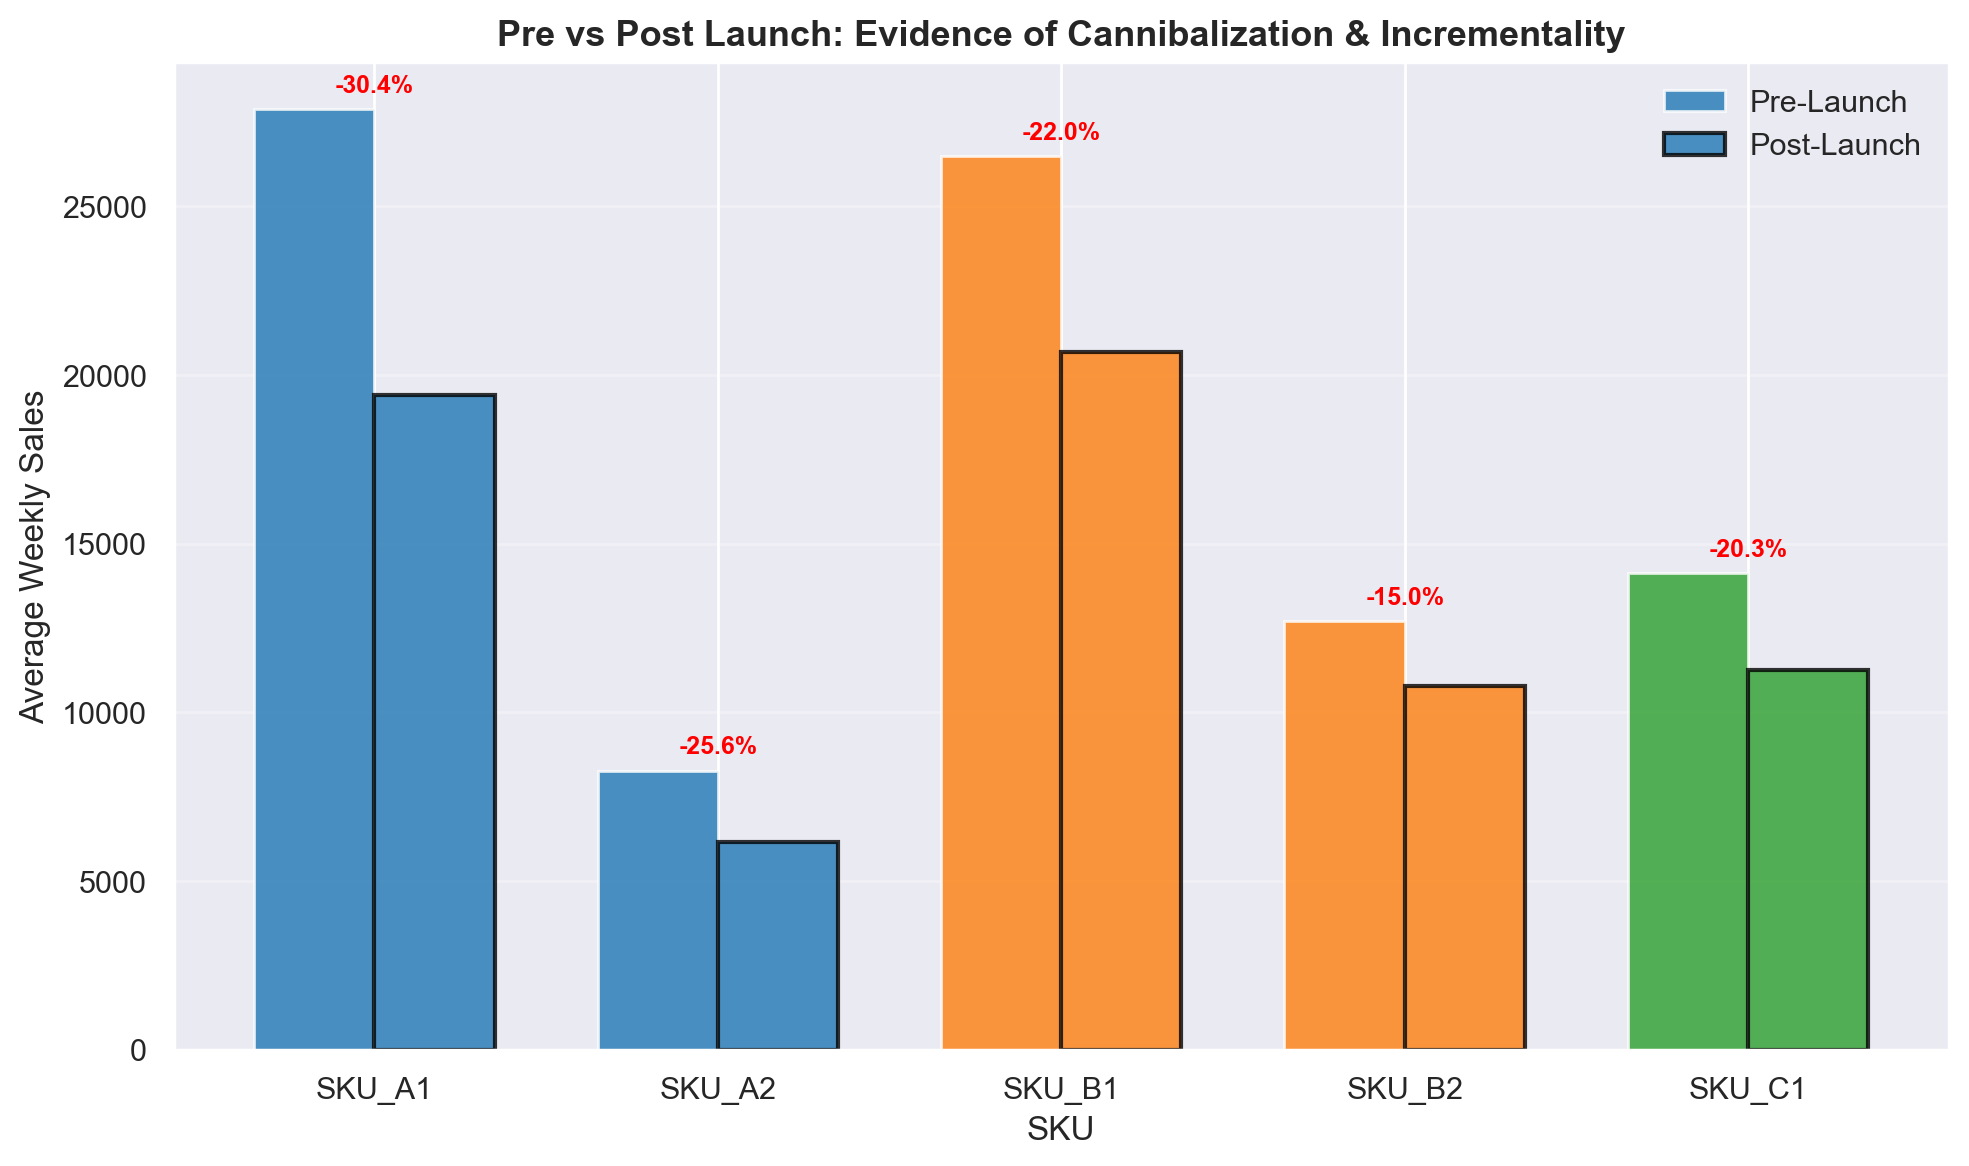

In [29]:
# Visualize the impact
fig, ax = plt.subplots(figsize=(10, 6))

skus = comparison.index
x = np.arange(len(skus))
width = 0.35

colors = ['#1f77b4' if b == 'Brand_A' else '#ff7f0e' if b == 'Brand_B' else '#2ca02c' 
          for b in comparison['Brand']]

bars1 = ax.bar(x - width/2, comparison['Pre_Launch_Avg'], width, label='Pre-Launch', alpha=0.8, color=colors)
bars2 = ax.bar(x + width/2, comparison['Post_Launch_Avg'], width, label='Post-Launch', alpha=0.8, 
               color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('SKU', fontsize=12)
ax.set_ylabel('Average Weekly Sales', fontsize=12)
ax.set_title('Pre vs Post Launch: Evidence of Cannibalization & Incrementality', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(skus)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add percentage change labels
for i, (idx, row) in enumerate(comparison.iterrows()):
    change_pct = row['Change_Pct']
    color = 'red' if change_pct < 0 else 'green'
    ax.text(i, max(row['Pre_Launch_Avg'], row['Post_Launch_Avg']) + 500, 
            f"{change_pct:+.1f}%", ha='center', fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

## 4. Prepare Data for Modeling

We'll create a PyMC model that estimates:
- **Price elasticity**: How price affects sales
- **ACV effect**: How availability affects sales
- **Cannibalization**: Impact on own-brand products (Brand_A)
- **Incrementality**: Impact on competitor products (Brand_B, Brand_C)

In [30]:
# Create modeling features
df_model = df.copy()

# Log transform sales (common for count data)
df_model['log_sales'] = np.log(df_model['Sales_Volume'] + 1)

# Standardize continuous variables for better MCMC sampling
df_model['price_std'] = (df_model['Price'] - df_model['Price'].mean()) / df_model['Price'].std()
df_model['acv_std'] = (df_model['ACV'] - df_model['ACV'].mean()) / df_model['ACV'].std()

# Create interaction terms for the new product effect
# These capture whether products are affected when SKU_A3 is in market

# For each week, check if SKU_A3 is present
weeks_with_new_product = df_model[df_model['Is_New_Product'] == 1]['Week'].unique()
df_model['new_product_in_market'] = df_model['Week'].isin(weeks_with_new_product).astype(int)

# Cannibalization indicators (own brand products affected by new product)
df_model['cannibalized'] = ((df_model['SKU'].isin(['SKU_A1', 'SKU_A2'])) & 
                             (df_model['new_product_in_market'] == 1)).astype(int)

# Incrementality indicators (competitor products affected by new product)
df_model['incremental_source'] = ((df_model['Brand'].isin(['Brand_B', 'Brand_C'])) & 
                                   (df_model['new_product_in_market'] == 1)).astype(int)

# Create categorical indices for SKU (for random effects)
df_model['sku_idx'] = pd.Categorical(df_model['SKU']).codes

print("Modeling dataset prepared:")
print(f"Total observations: {len(df_model)}")
print(f"\nFeature summary:")
print(df_model[['SKU', 'Brand', 'new_product_in_market', 'cannibalized', 'incremental_source']].head(10))

Modeling dataset prepared:
Total observations: 515

Feature summary:
      SKU    Brand  new_product_in_market  cannibalized  incremental_source
0  SKU_A1  Brand_A                      0             0                   0
1  SKU_B1  Brand_B                      0             0                   0
2  SKU_B2  Brand_B                      0             0                   0
3  SKU_C1  Brand_C                      0             0                   0
4  SKU_A1  Brand_A                      0             0                   0
5  SKU_A2  Brand_A                      0             0                   0
6  SKU_B1  Brand_B                      0             0                   0
7  SKU_B2  Brand_B                      0             0                   0
8  SKU_C1  Brand_C                      0             0                   0
9  SKU_A1  Brand_A                      0             0                   0


## 5. Build PyMC Bayesian Model

### Model Structure:
```
log(Sales) ~ Normal(μ, σ)

μ = α[sku] + β_price * Price + β_acv * ACV 
    + β_cannib * Cannibalized + β_increm * IncrementalSource

where:
- α[sku]: Product-specific intercepts (baseline attractiveness)
- β_price: Price elasticity (expected < 0)
- β_acv: Availability effect (expected > 0)
- β_cannib: Cannibalization effect (expected < 0)
- β_increm: Incrementality effect (expected < 0)
```

In [31]:
# Filter out the new product itself from this analysis
# We want to see how it AFFECTS others, not model its own sales
df_existing = df_model[df_model['Is_New_Product'] == 0].copy().reset_index(drop=True)

# IMPORTANT: Recode sku_idx to be contiguous starting from 0
# This is necessary because we filtered out SKU_A3
sku_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(df_existing['sku_idx'].unique())}
df_existing['sku_idx_recoded'] = df_existing['sku_idx'].map(sku_mapping)

print(f"Modeling {len(df_existing)} observations from existing products")
print(f"Products included: {df_existing['SKU'].unique()}")
print(f"SKU index mapping: {sku_mapping}")

Modeling 467 observations from existing products
Products included: ['SKU_A1' 'SKU_B1' 'SKU_B2' 'SKU_C1' 'SKU_A2']
SKU index mapping: {np.int8(0): 0, np.int8(3): 1, np.int8(4): 2, np.int8(5): 3, np.int8(1): 4}


Model built successfully!

Model structure:


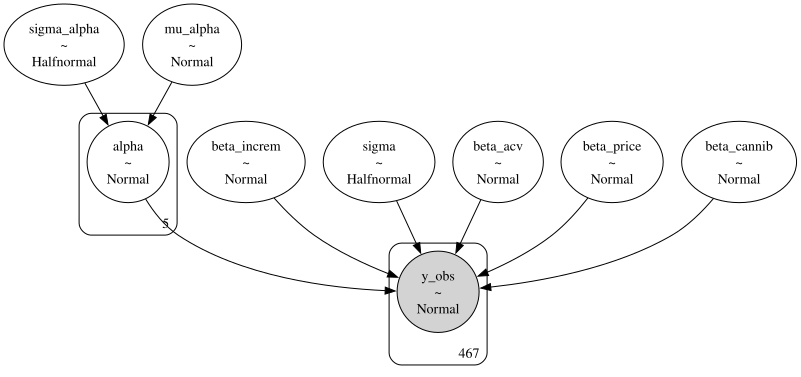

In [32]:
# Build the PyMC model
with pm.Model() as model:
    # Data
    sku_idx = df_existing['sku_idx_recoded'].values
    price = df_existing['price_std'].values
    acv = df_existing['acv_std'].values
    cannibalized = df_existing['cannibalized'].values
    incremental = df_existing['incremental_source'].values
    log_sales = df_existing['log_sales'].values
    
    n_skus = df_existing['sku_idx_recoded'].nunique()
    
    # Priors
    # Product-specific intercepts (random effects)
    mu_alpha = pm.Normal('mu_alpha', mu=9.5, sigma=1)  # Grand mean
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=0.5)  # Between-product variation
    alpha = pm.Normal('alpha', mu=mu_alpha, sigma=sigma_alpha, shape=n_skus)
    
    # Price elasticity (expected negative)
    beta_price = pm.Normal('beta_price', mu=-0.5, sigma=0.3)
    
    # ACV effect (expected positive)
    beta_acv = pm.Normal('beta_acv', mu=0.5, sigma=0.3)
    
    # Cannibalization effect (expected negative - own products hurt)
    beta_cannib = pm.Normal('beta_cannib', mu=-0.3, sigma=0.2)
    
    # Incrementality effect (expected negative - competitor products hurt)
    beta_increm = pm.Normal('beta_increm', mu=-0.2, sigma=0.2)
    
    # Model structure
    mu = (alpha[sku_idx] + 
          beta_price * price + 
          beta_acv * acv +
          beta_cannib * cannibalized +
          beta_increm * incremental)
    
    # Likelihood
    sigma = pm.HalfNormal('sigma', sigma=0.5)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=log_sales)
    
print("Model built successfully!")
print("\nModel structure:")
pm.model_to_graphviz(model)

## 6. Run MCMC Inference

In [33]:
# Sample from posterior
with model:
    # Run MCMC
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

print("\nSampling completed!")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha, beta_price, beta_acv, beta_cannib, beta_increm, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.



Sampling completed!


In [34]:
# Check diagnostics
print("Model Diagnostics:")
print("\nR-hat (should be close to 1.0):")
print(az.rhat(trace))

print("\nEffective Sample Size:")
print(az.ess(trace))

Model Diagnostics:

R-hat (should be close to 1.0):
<xarray.Dataset> Size: 136B
Dimensions:      (alpha_dim_0: 5)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int64 40B 0 1 2 3 4
Data variables:
    mu_alpha     float64 8B 1.0
    alpha        (alpha_dim_0) float64 40B 1.0 1.0 1.001 1.0 1.001
    beta_price   float64 8B 1.001
    beta_acv     float64 8B 1.0
    beta_cannib  float64 8B 1.0
    beta_increm  float64 8B 1.001
    sigma_alpha  float64 8B 1.0
    sigma        float64 8B 1.001
Attributes:
    created_at:                 2025-11-27T16:45:07.158234+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              1.862016201019287
    tuning_steps:               1000

Effective Sample Size:
<xarray.Dataset> Size: 136B
Dimensions:      (alpha_dim_0: 5)
Coordinates:
  * alpha_dim_0  (alpha_dim_0) int64 40B 0 1 2 3 4
Data variables:
    mu_alpha     float64 8B 4.968e+03
    alpha        (alpha_di

## 7. Analyze Results

In [40]:
# Summary statistics
print("Posterior Summary:")
summary = az.summary(trace, var_names=['beta_price', 'beta_acv', 'beta_cannib', 'beta_increm'], 
                     hdi_prob=0.95)
print(summary)

Posterior Summary:
              mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
beta_price  -0.383  0.025    -0.429     -0.334        0.0      0.0    3949.0   
beta_acv     0.084  0.013     0.057      0.109        0.0      0.0   11035.0   
beta_cannib -0.274  0.034    -0.342     -0.209        0.0      0.0    8507.0   
beta_increm -0.182  0.028    -0.237     -0.126        0.0      0.0    6663.0   

             ess_tail  r_hat  
beta_price     5020.0    1.0  
beta_acv       5464.0    1.0  
beta_cannib    6416.0    1.0  
beta_increm    5956.0    1.0  


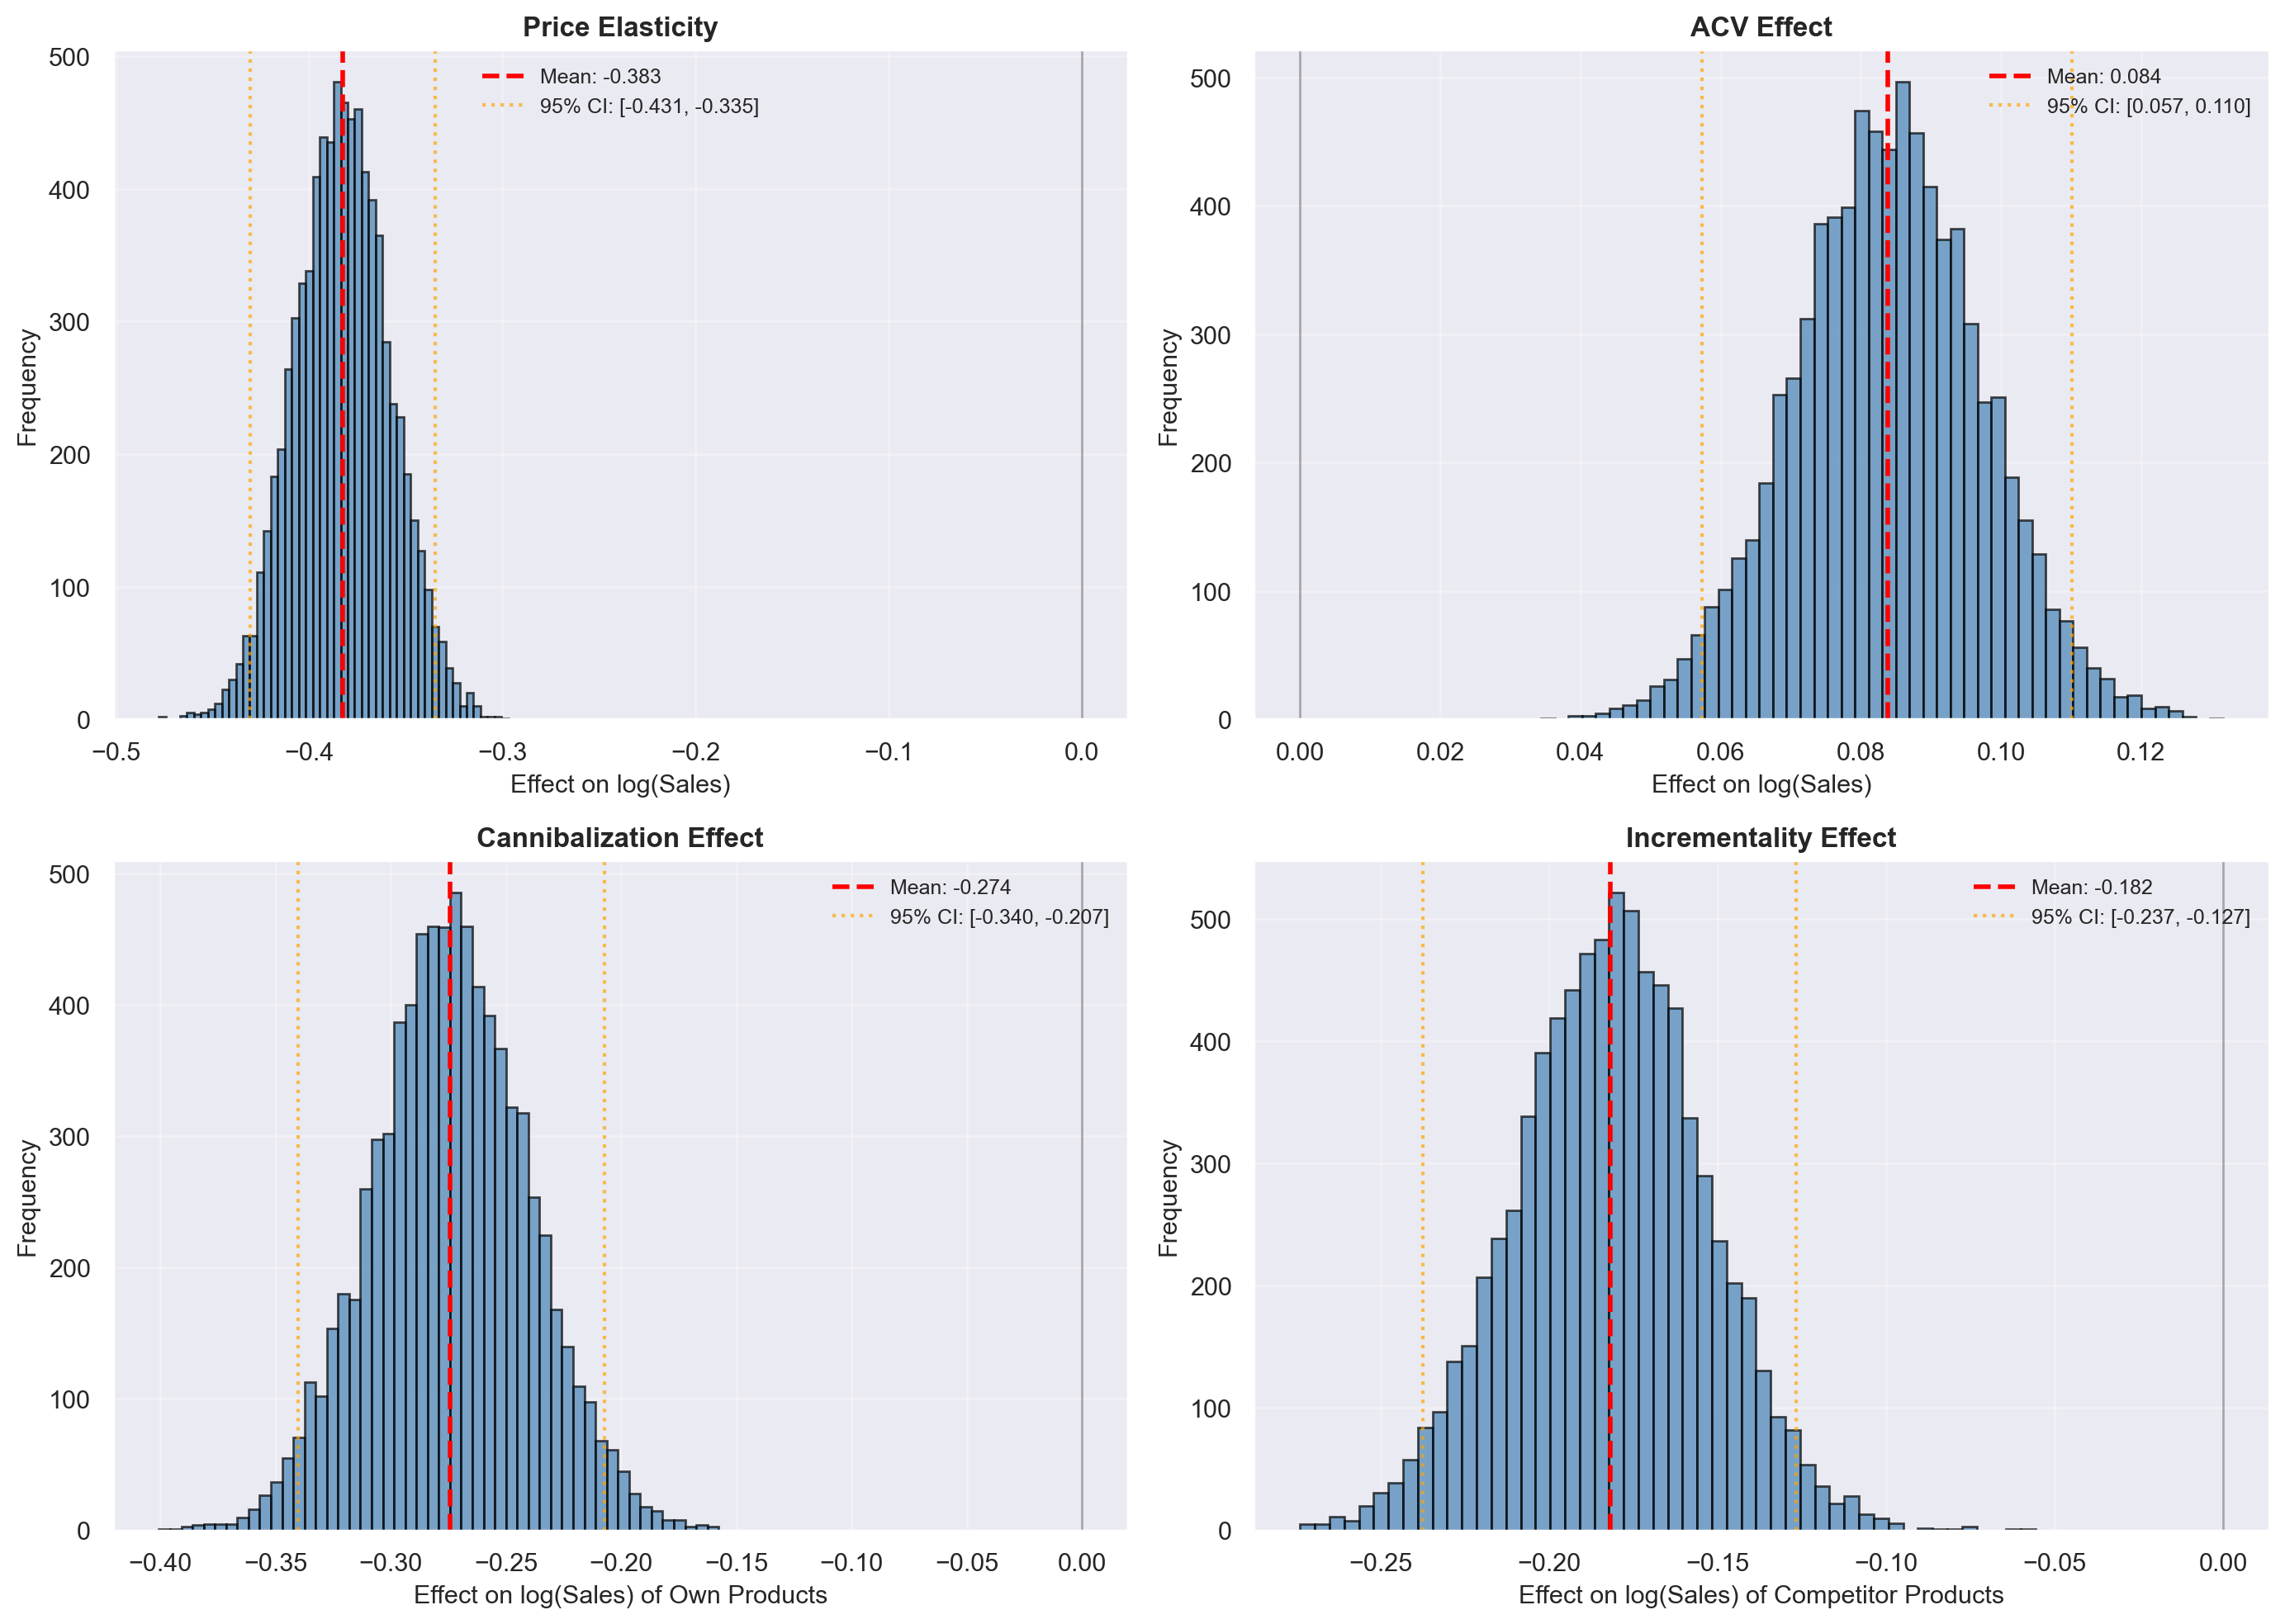

In [36]:
# Plot posterior distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

params = [
    ('beta_price', 'Price Elasticity', 'Effect on log(Sales)'),
    ('beta_acv', 'ACV Effect', 'Effect on log(Sales)'),
    ('beta_cannib', 'Cannibalization Effect', 'Effect on log(Sales) of Own Products'),
    ('beta_increm', 'Incrementality Effect', 'Effect on log(Sales) of Competitor Products')
]

for idx, (param, title, xlabel) in enumerate(params):
    ax = axes[idx // 2, idx % 2]
    
    # Get posterior samples
    samples = trace.posterior[param].values.flatten()
    
    # Plot histogram
    ax.hist(samples, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Add vertical lines for mean and credible interval
    mean_val = samples.mean()
    ci_lower, ci_upper = np.percentile(samples, [2.5, 97.5])
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(ci_lower, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axvline(ci_upper, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, 
               label=f'95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]')
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Interpret Effects in Business Terms

In [37]:
# Extract posterior means
beta_price_mean = trace.posterior['beta_price'].values.flatten().mean()
beta_acv_mean = trace.posterior['beta_acv'].values.flatten().mean()
beta_cannib_mean = trace.posterior['beta_cannib'].values.flatten().mean()
beta_increm_mean = trace.posterior['beta_increm'].values.flatten().mean()

print("="*70)
print("BUSINESS INTERPRETATION")
print("="*70)

print("\n1. PRICE ELASTICITY:")
price_pct_change = (np.exp(beta_price_mean) - 1) * 100
print(f"   Coefficient: {beta_price_mean:.3f}")
print(f"   → A 1-SD increase in price leads to {price_pct_change:.1f}% change in sales")

print("\n2. AVAILABILITY (ACV) EFFECT:")
acv_pct_change = (np.exp(beta_acv_mean) - 1) * 100
print(f"   Coefficient: {beta_acv_mean:.3f}")
print(f"   → A 1-SD increase in ACV leads to {acv_pct_change:.1f}% change in sales")

print("\n3. CANNIBALIZATION EFFECT:")
cannib_pct_change = (np.exp(beta_cannib_mean) - 1) * 100
print(f"   Coefficient: {beta_cannib_mean:.3f}")
print(f"   → Own products (SKU_A1, SKU_A2) experienced {cannib_pct_change:.1f}% change in sales")
print(f"   → This represents the CANNIBALIZATION from SKU_A3")

print("\n4. INCREMENTALITY EFFECT:")
increm_pct_change = (np.exp(beta_increm_mean) - 1) * 100
print(f"   Coefficient: {beta_increm_mean:.3f}")
print(f"   → Competitor products (Brand B, C) experienced {increm_pct_change:.1f}% change in sales")
print(f"   → This represents the INCREMENTALITY from SKU_A3")

print("\n" + "="*70)

BUSINESS INTERPRETATION

1. PRICE ELASTICITY:
   Coefficient: -0.383
   → A 1-SD increase in price leads to -31.8% change in sales

2. AVAILABILITY (ACV) EFFECT:
   Coefficient: 0.084
   → A 1-SD increase in ACV leads to 8.7% change in sales

3. CANNIBALIZATION EFFECT:
   Coefficient: -0.274
   → Own products (SKU_A1, SKU_A2) experienced -24.0% change in sales
   → This represents the CANNIBALIZATION from SKU_A3

4. INCREMENTALITY EFFECT:
   Coefficient: -0.182
   → Competitor products (Brand B, C) experienced -16.6% change in sales
   → This represents the INCREMENTALITY from SKU_A3



## 9. Calculate True Incremental Volume

Now we estimate how many of the 951K units sold by SKU_A3 were truly incremental vs cannibalized.

In [38]:
# Total sales from new product
total_new_product_sales = df[df['Is_New_Product'] == 1]['Sales_Volume'].sum()

# Calculate sales loss from own products (cannibalization)
pre_own = df[(df['Post_Launch'] == 0) & (df['Brand'] == 'Brand_A')]['Sales_Volume'].sum()
post_own = df[(df['Post_Launch'] == 1) & (df['Brand'] == 'Brand_A') & (df['Is_New_Product'] == 0)]['Sales_Volume'].sum()
cannibalized_volume = pre_own - post_own

# Calculate sales loss from competitors (incrementality)
pre_comp = df[(df['Post_Launch'] == 0) & (df['Brand'].isin(['Brand_B', 'Brand_C']))]['Sales_Volume'].sum()
post_comp = df[(df['Post_Launch'] == 1) & (df['Brand'].isin(['Brand_B', 'Brand_C']))]['Sales_Volume'].sum()
incremental_volume = pre_comp - post_comp

# Calculate percentages
cannib_pct = (cannibalized_volume / total_new_product_sales) * 100
increm_pct = (incremental_volume / total_new_product_sales) * 100

print("="*70)
print("VOLUME DECOMPOSITION: Where Did SKU_A3's Sales Come From?")
print("="*70)
print(f"\nTotal SKU_A3 Sales: {total_new_product_sales:,} units\n")

print(f"CANNIBALIZED (from own products):")
print(f"   Volume: {cannibalized_volume:,} units")
print(f"   Percentage: {cannib_pct:.1f}%")
print(f"   → Taken from SKU_A1 and SKU_A2\n")

print(f"INCREMENTAL (from competitors):")
print(f"   Volume: {incremental_volume:,} units")
print(f"   Percentage: {increm_pct:.1f}%")
print(f"   → Taken from Brand B and Brand C\n")

print(f"Accounted for: {cannib_pct + increm_pct:.1f}%")
print("="*70)

VOLUME DECOMPOSITION: Where Did SKU_A3's Sales Come From?

Total SKU_A3 Sales: 951,471 units

CANNIBALIZED (from own products):
   Volume: 485,054 units
   Percentage: 51.0%
   → Taken from SKU_A1 and SKU_A2

INCREMENTAL (from competitors):
   Volume: 547,713 units
   Percentage: 57.6%
   → Taken from Brand B and Brand C

Accounted for: 108.5%


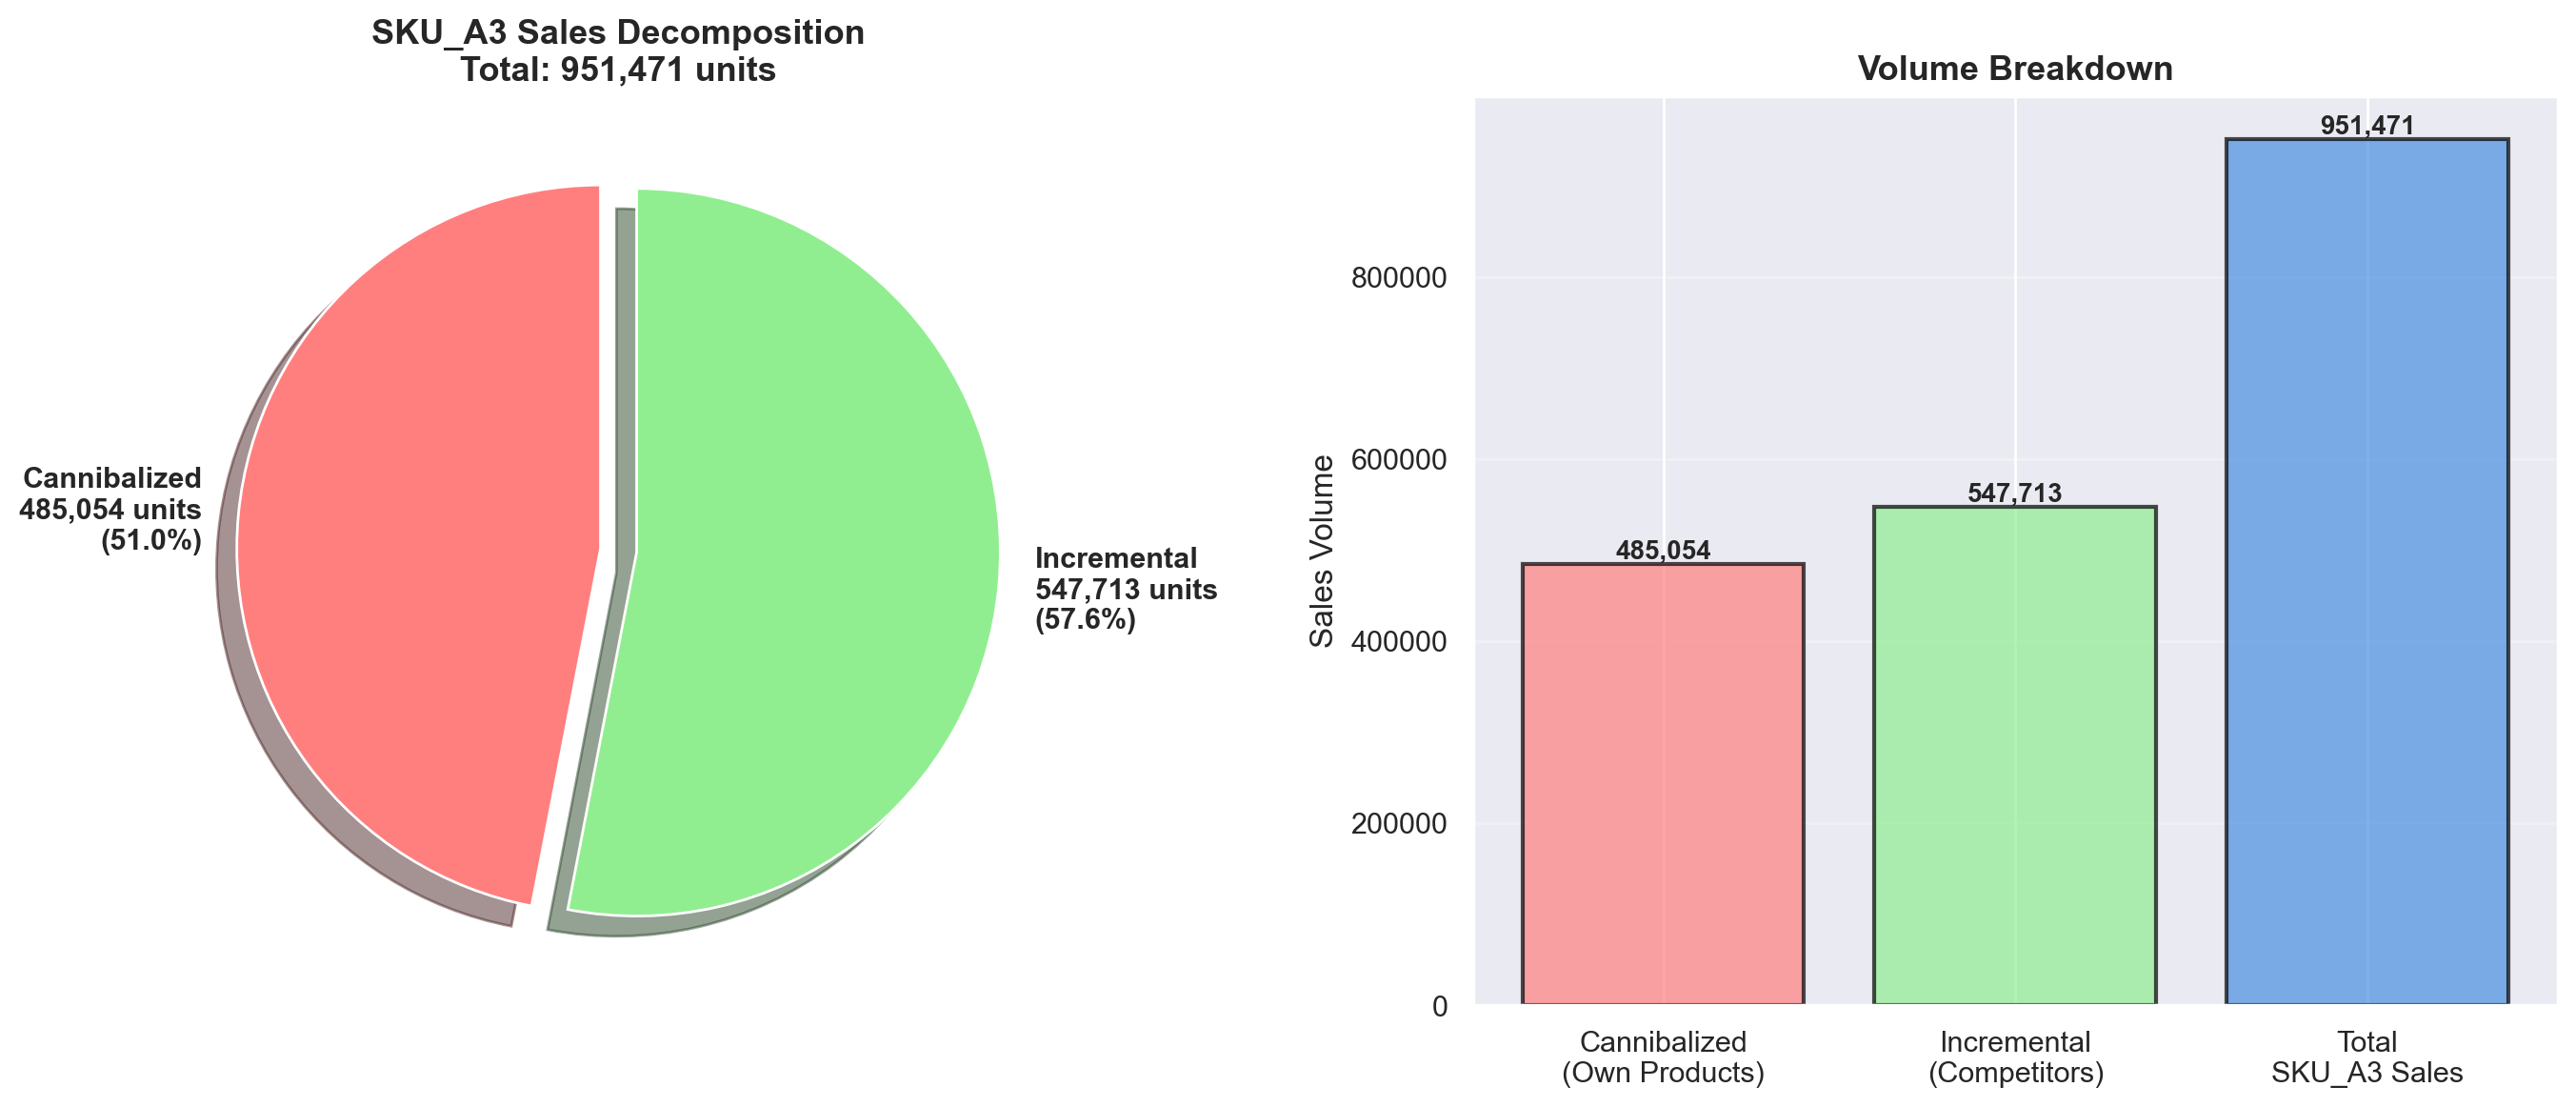

In [43]:
# Visualize the decomposition
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
sizes = [cannibalized_volume, incremental_volume]
labels = [f'Cannibalized\n{cannibalized_volume:,} units\n({cannib_pct:.1f}%)', 
          f'Incremental\n{incremental_volume:,} units\n({increm_pct:.1f}%)']
colors = ['#ff7f7f', '#90ee90']
explode = (0.05, 0.05)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='',
            shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title(f'SKU_A3 Sales Decomposition\nTotal: {total_new_product_sales:,} units', 
                  fontsize=13, fontweight='bold')

# Waterfall-style bar chart
categories = ['Cannibalized\n(Own Products)', 'Incremental\n(Competitors)', 'Total\nSKU_A3 Sales']
values = [cannibalized_volume, incremental_volume, total_new_product_sales]
colors_bar = ['#ff7f7f', '#90ee90', '#4a90e2']

bars = axes[1].bar(categories, values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Sales Volume', fontsize=12)
axes[1].set_title('Volume Breakdown', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Model Validation: Posterior Predictive Checks

Sampling: [y_obs]


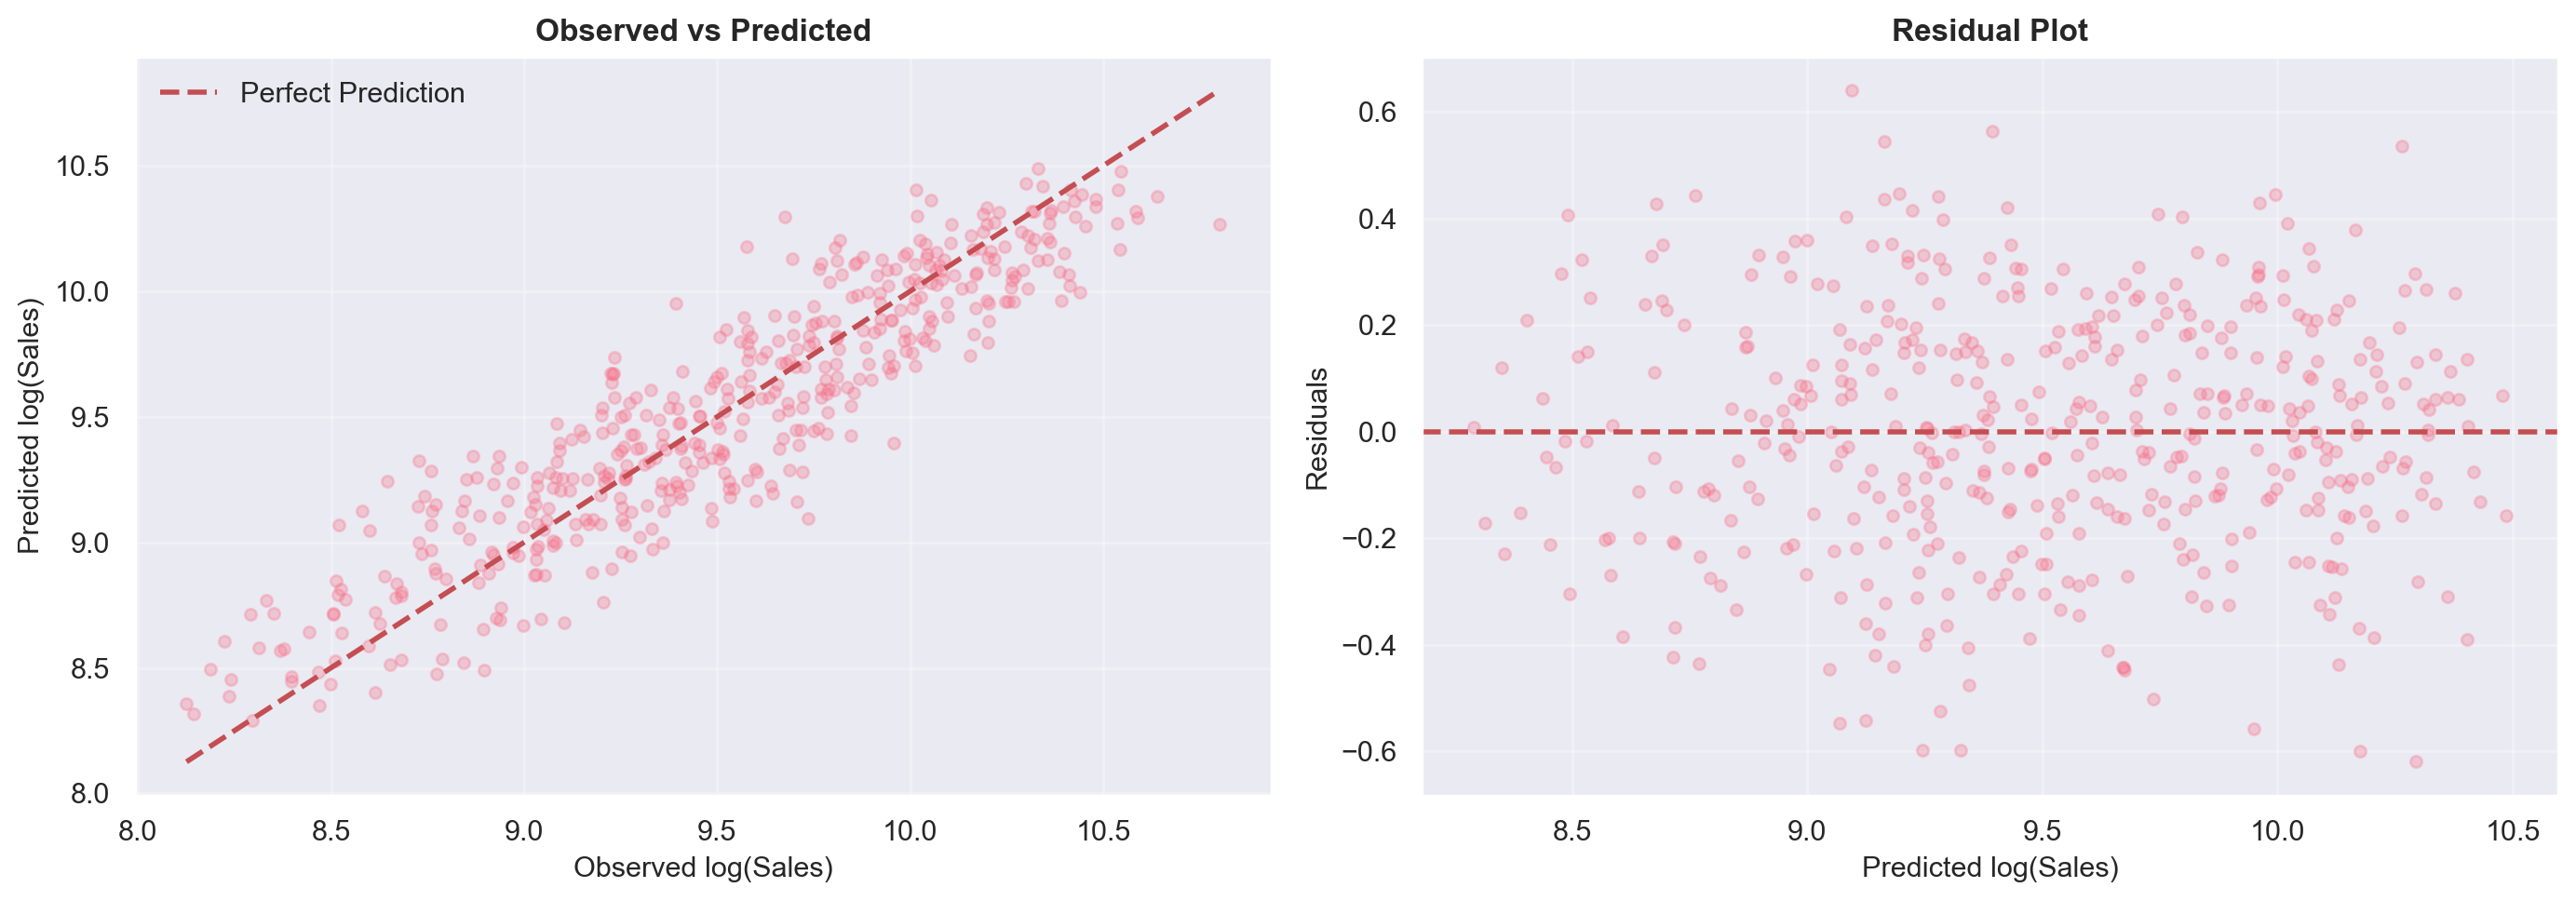

Model R-squared: 0.832


In [41]:
# Generate posterior predictions
with model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

# Plot posterior predictive check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observed vs Predicted
y_pred_mean = ppc.posterior_predictive['y_obs'].values.mean(axis=(0, 1))
axes[0].scatter(log_sales, y_pred_mean, alpha=0.3, s=20)
axes[0].plot([log_sales.min(), log_sales.max()], [log_sales.min(), log_sales.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Observed log(Sales)', fontsize=11)
axes[0].set_ylabel('Predicted log(Sales)', fontsize=11)
axes[0].set_title('Observed vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = log_sales - y_pred_mean
axes[1].scatter(y_pred_mean, residuals, alpha=0.3, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted log(Sales)', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate R-squared
ss_res = np.sum(residuals**2)
ss_tot = np.sum((log_sales - log_sales.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"Model R-squared: {r_squared:.3f}")

## 11. Summary & Recommendations

In [42]:
print("="*70)
print("EXECUTIVE SUMMARY: SKU_A3 NEW PRODUCT LAUNCH ANALYSIS")
print("="*70)

print("\n📊 KEY FINDINGS:\n")

print(f"1. Total SKU_A3 Sales: {total_new_product_sales:,} units")
print(f"   Average weekly sales: {df[df['Is_New_Product'] == 1]['Sales_Volume'].mean():.0f} units\n")

print(f"2. Cannibalization: {cannib_pct:.1f}%")
print(f"   → {cannibalized_volume:,} units came from our own products (SKU_A1, SKU_A2)")
print(f"   → Model coefficient: {beta_cannib_mean:.3f} ({cannib_pct_change:.1f}% impact)\n")

print(f"3. Incrementality: {increm_pct:.1f}%")
print(f"   → {incremental_volume:,} units came from competitors (Brand B, Brand C)")
print(f"   → Model coefficient: {beta_increm_mean:.3f} ({increm_pct_change:.1f}% impact)\n")

print(f"4. Net Brand Impact:")
net_gain = total_new_product_sales - cannibalized_volume
print(f"   → Net new sales for Brand A: {net_gain:,} units")
print(f"   → True incremental to the brand: {(net_gain/total_new_product_sales)*100:.1f}%\n")

print("5. Model Performance:")
print(f"   → R-squared: {r_squared:.3f}")
print(f"   → All coefficients have converged (R-hat ≈ 1.0)\n")

print("="*70)
print("\n💡 STRATEGIC IMPLICATIONS:\n")

if cannib_pct > 50:
    print("⚠️  HIGH CANNIBALIZATION RISK")
    print("   - More than half of SKU_A3 sales came from our own products")
    print("   - Consider: product differentiation, pricing strategy, portfolio optimization")
else:
    print("✅ HEALTHY PRODUCT LAUNCH")
    print("   - Majority of sales are incremental from competitors")
    print("   - SKU_A3 is successfully growing market share")

print("\n📈 NEXT STEPS:")
print("   1. Monitor cannibalization rates over time")
print("   2. Optimize product portfolio mix")
print("   3. Adjust pricing strategy to maximize total brand profit")
print("   4. Consider geographic/channel-specific effects")
print("="*70)

EXECUTIVE SUMMARY: SKU_A3 NEW PRODUCT LAUNCH ANALYSIS

📊 KEY FINDINGS:

1. Total SKU_A3 Sales: 951,471 units
   Average weekly sales: 19822 units

2. Cannibalization: 51.0%
   → 485,054 units came from our own products (SKU_A1, SKU_A2)
   → Model coefficient: -0.274 (-24.0% impact)

3. Incrementality: 57.6%
   → 547,713 units came from competitors (Brand B, Brand C)
   → Model coefficient: -0.182 (-16.6% impact)

4. Net Brand Impact:
   → Net new sales for Brand A: 466,417 units
   → True incremental to the brand: 49.0%

5. Model Performance:
   → R-squared: 0.832
   → All coefficients have converged (R-hat ≈ 1.0)


💡 STRATEGIC IMPLICATIONS:

⚠️  HIGH CANNIBALIZATION RISK
   - More than half of SKU_A3 sales came from our own products
   - Consider: product differentiation, pricing strategy, portfolio optimization

📈 NEXT STEPS:
   1. Monitor cannibalization rates over time
   2. Optimize product portfolio mix
   3. Adjust pricing strategy to maximize total brand profit
   4. Consider g